<a href="https://colab.research.google.com/github/liuruijie744-sys/MLLM/blob/main/Assignment_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IIDS67692 Computational Techniques for Multi-modal Data
##Assignment Part-B: Multimodal Fusion and LoRA Adaptation for Heath Decision Support



In [1]:
!nvidia-smi

Mon Jun  1 01:24:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

###Installing required python packages

In [4]:
%pip install -q --prefer-binary --only-binary=:all: "tokenizers==0.22.2" safetensors
%pip install -q --prefer-binary datasets evaluate bert_score rouge_score transformers peft gdown accelerate ipywidgets nltk

#Dataset

Huggingface Link: https://huggingface.co/datasets/flaviagiammarino/path-vqa

The PathVQA Dataset is available on Hugging Face and contains 19,654 training, 6,259 validation, and 6,719 test question-answer pairs across approximately 5,004 pathology images.

The PathVQA Dataset is a large-scale medical visual question answering benchmark designed for pathology image understanding. It contains more than 32,000 question-answer pairs associated with pathology images collected from publicly available medical sources. The dataset supports multimodal AI research by combining visual pathology information with natural language reasoning tasks, enabling models to answer clinically relevant questions about tissue appearance, disease characteristics, and diagnostic findings. PathVQA has become a widely used benchmark for evaluating medical VQA systems and multimodal large language models in digital pathology research.

[1] He, Xuehai, et al. "Towards visual question answering on pathology images." Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics and the 11th International Joint Conference on Natural Language Processing (Volume 2: Short Papers). 2021.

[2] He, Xuehai, et al. "Pathvqa: 30000+ questions for medical visual question answering." arXiv preprint arXiv:2003.10286 (2020).

PathVQA validation samples: 6259
Dataset keys: dict_keys(['image', 'question', 'answer'])
Dataset features:
{'image': Image(mode=None, decode=True), 'question': Value('string'), 'answer': Value('string')}


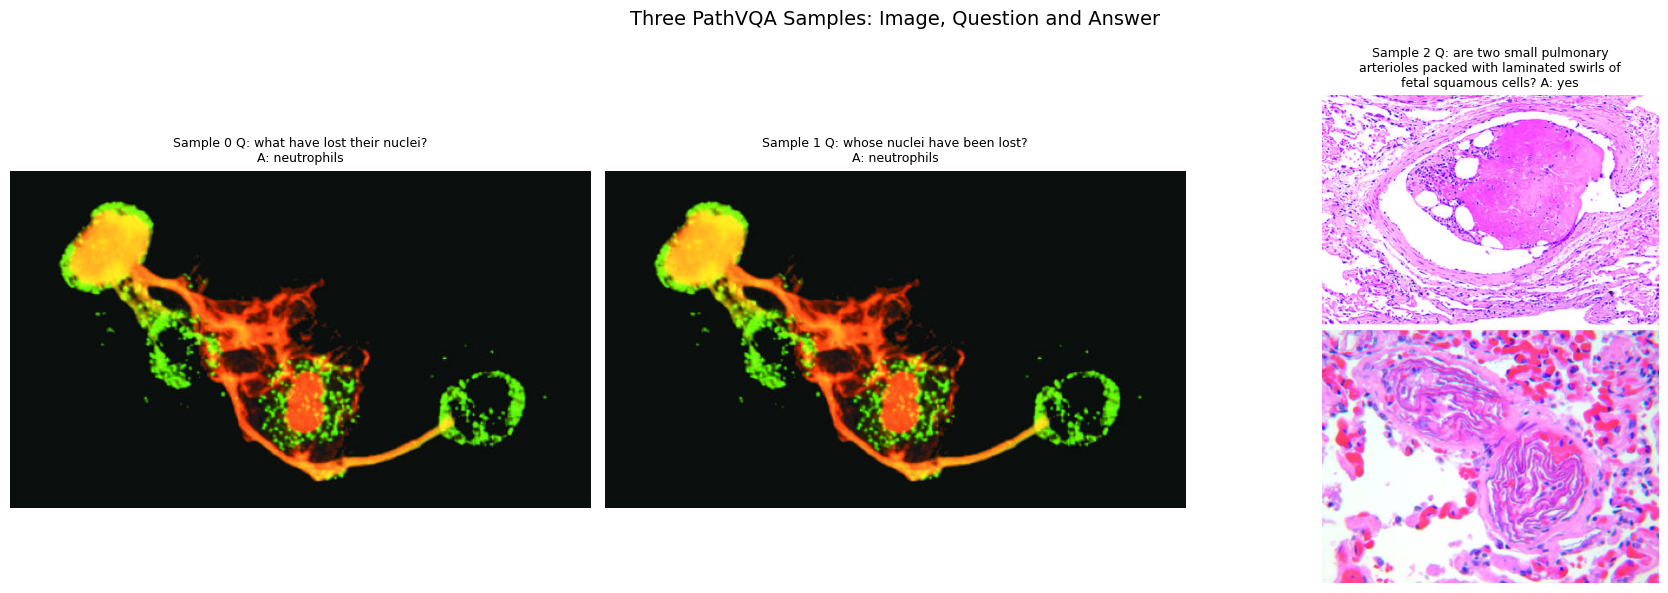

In [8]:
from datasets import load_dataset
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# Load PathVQA validation split
pathvqa_valid = load_dataset(
    "parquet",
    data_files={
        "validation": "hf://datasets/flaviagiammarino/path-vqa/data/validation-*.parquet"
    },
    split="validation"
)

print("PathVQA validation samples:", len(pathvqa_valid))
print("Dataset keys:", pathvqa_valid[0].keys())
print("Dataset features:")
print(pathvqa_valid.features)

# Visualise 3 image-question-answer samples
sample_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, idx in zip(axes, sample_indices):
    sample = pathvqa_valid[idx]
    image = sample["image"].convert("RGB")
    question = sample["question"]
    answer = sample["answer"]

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        textwrap.fill(f"Sample {idx}\nQ: {question}\nA: {answer}", width=42),
        fontsize=9
    )

plt.suptitle("Three PathVQA Samples: Image, Question and Answer", fontsize=14)
plt.tight_layout()
plt.show()

#Prepare Dataloader

Device: cuda
Train: 2400
Validation: 600
Processed image tensor shape: torch.Size([3, 224, 224])
Question: is gross islands of tumor?
Answer: yes


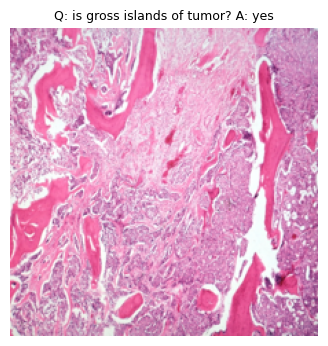

In [10]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import InterpolationMode

from transformers import AutoTokenizer
from tqdm.auto import tqdm

# Reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(42)


class PathVQADataset(Dataset):
    def __init__(self, hf_dataset):
        """
        hf_dataset: Hugging Face dataset split containing image, question, and answer fields.
        """
        self.dataset = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"].convert("RGB")
        image = self.transform(image)

        question = sample["question"]
        answer = sample["answer"]

        return image, question, answer


# Use subset for this assignment
subset = pathvqa_valid.shuffle(seed=42).select(range(3000))
split_dataset = subset.train_test_split(test_size=0.2, seed=42)

train_data = split_dataset["train"]
val_data = split_dataset["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))

train_dataset = PathVQADataset(train_data)
val_dataset = PathVQADataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# GPT-2 tokenizer for question-answer text
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

SEQ_LEN = 68

# Check one processed sample
img, question, answer = train_dataset[1]
print("Processed image tensor shape:", img.shape)
print("Question:", question)
print("Answer:", answer)

plt.figure(figsize=(4, 4))
plt.axis("off")
plt.imshow(img.permute(1, 2, 0))
plt.title(textwrap.fill(f"Q: {question}\nA: {answer}", width=50), fontsize=9)
plt.show()


#Model Architecture

Paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

GPT-2 uses a decoder-only transformer architecture with multiple model sizes; the commonly used GPT-2 Base model contains 12 transformer blocks (layers), a context window of 1024 tokens, a hidden embedding size of 768, and about 117 million parameters, while larger variants scale up to 48 transformer blocks and 1.5 billion parameters.

[1] Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI blog, 1(8), 9.

###Cross-Attention Fusion

In [11]:
import torch
import torch.nn as nn


class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=4, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        """
        attended_text, _ = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))

        return x

###Gated Cross-Attention Fusion

In [12]:
#Write your code for Gated-Cross Attention Fusion
class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=4, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Gate controls how much visual information should be injected into the text features.
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        Gated cross-attention uses the same text-to-image attention as standard
        cross-attention, but adds a learnable gate:

            fused = text_embeds + gate * attended_visual_features

        This makes the model learn how much visual information should influence
        each text token, which is useful for noisy or complex medical images.
        """
        attended_text, _ = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        gate_value = self.gate(torch.cat([text_embeds, attended_text], dim=-1))
        fused = text_embeds + gate_value * attended_text

        x = self.norm1(fused)
        x = self.norm2(x + self.ffn(x))

        return x

###MedVQA model (Mulitmodal GPT2)

In [13]:
from transformers import AutoModelForCausalLM, ViTModel
from peft import get_peft_model, TaskType, LoraConfig


class MedVQA(nn.Module):
    def __init__(
        self,
        fusion_type="cross",
        num_heads=4,
        lora_r=8,
        lora_alpha=16,
        lora_dropout=0.1
    ):
        super().__init__()

        # Visual encoder: ViT extracts image patch embeddings.
        self.visual_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

        # Freeze all visual encoder parameters to reduce training cost.
        for p in self.visual_encoder.parameters():
            p.requires_grad = False

        # GPT-2 decoder with LoRA adaptation.
        gpt = AutoModelForCausalLM.from_pretrained("gpt2")
        gpt.config.pad_token_id = tokenizer.eos_token_id

        lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["c_attn", "c_proj"]
        )

        self.gpt = get_peft_model(gpt, lora_config)

        # Select the fusion module.
        if fusion_type == "cross":
            self.fusion = CrossAttentionFusion(num_heads=num_heads)
        elif fusion_type == "gated":
            self.fusion = GatedCrossAttentionFusion(num_heads=num_heads)
        else:
            raise ValueError("fusion_type must be 'cross' or 'gated'")

    def forward(self, image, input_ids, attention_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        text_embeds = self.gpt.get_input_embeddings()(input_ids)

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=attention_mask
        )

        output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=attention_mask
        )

        return output.logits

W0601 01:36:00.009000 784 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0601 01:36:00.151000 784 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


#Model Training

In [14]:
#Training Script for Multimodal GPT2 with LoRA
def prepare_inputs(questions, answers):
    prompts = [
        f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
        for q, a in zip(questions, answers)
    ]

    encoded = tokenizer(
        prompts,
        padding="max_length",
        truncation=True,
        max_length=SEQ_LEN,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    labels = input_ids.clone()
    labels[attention_mask == 0] = -100

    # Mask the question part, so the loss is calculated mainly on the answer tokens.
    for i, q in enumerate(questions):
        q_prompt = f"Question: {q}\nAnswer:"
        q_len = len(tokenizer(q_prompt, add_special_tokens=False)["input_ids"])
        labels[i, :q_len] = -100

    return input_ids, attention_mask, labels


def train_model(model, train_loader, val_loader, epochs=3, lr=2e-4):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for images, questions, answers in tqdm(train_loader, desc=f"Training epoch {epoch}"):
            images = images.to(device)
            input_ids, attention_mask, labels = prepare_inputs(questions, answers)

            logits = model(images, input_ids, attention_mask)

            loss = criterion(
                logits[:, :-1, :].reshape(-1, logits.size(-1)),
                labels[:, 1:].reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for images, questions, answers in tqdm(val_loader, desc=f"Validation epoch {epoch}"):
                images = images.to(device)
                input_ids, attention_mask, labels = prepare_inputs(questions, answers)

                logits = model(images, input_ids, attention_mask)

                loss = criterion(
                    logits[:, :-1, :].reshape(-1, logits.size(-1)),
                    labels[:, 1:].reshape(-1)
                )

                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# Train standard Cross-Attention model
cross_model = MedVQA(
    fusion_type="cross",
    num_heads=4
)

cross_model = train_model(
    model=cross_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=3,
    lr=2e-4
)


# Train Gated Cross-Attention model
gated_model = MedVQA(
    fusion_type="gated",
    num_heads=4
)

gated_model = train_model(
    model=gated_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=3,
    lr=2e-4
)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Validation epoch 2:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 3.0589 | Val Loss: 2.6454


Training epoch 3:   0%|          | 0/75 [00:00<?, ?it/s]

Validation epoch 3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 2.6854 | Val Loss: 2.4990


#Inference: few samples (prediction visualisations)

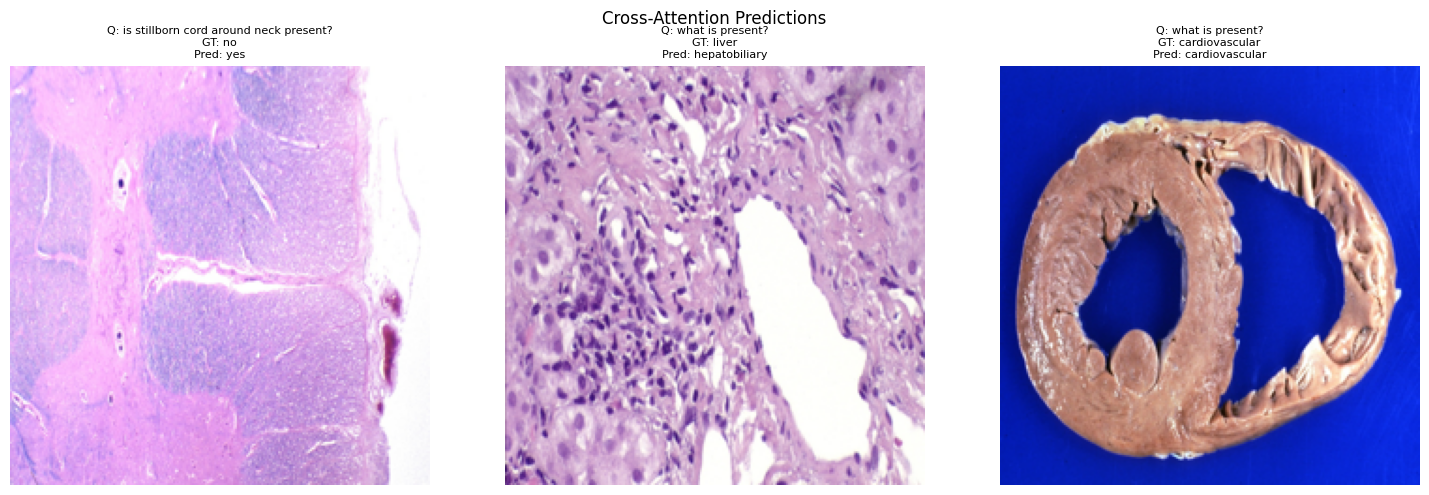

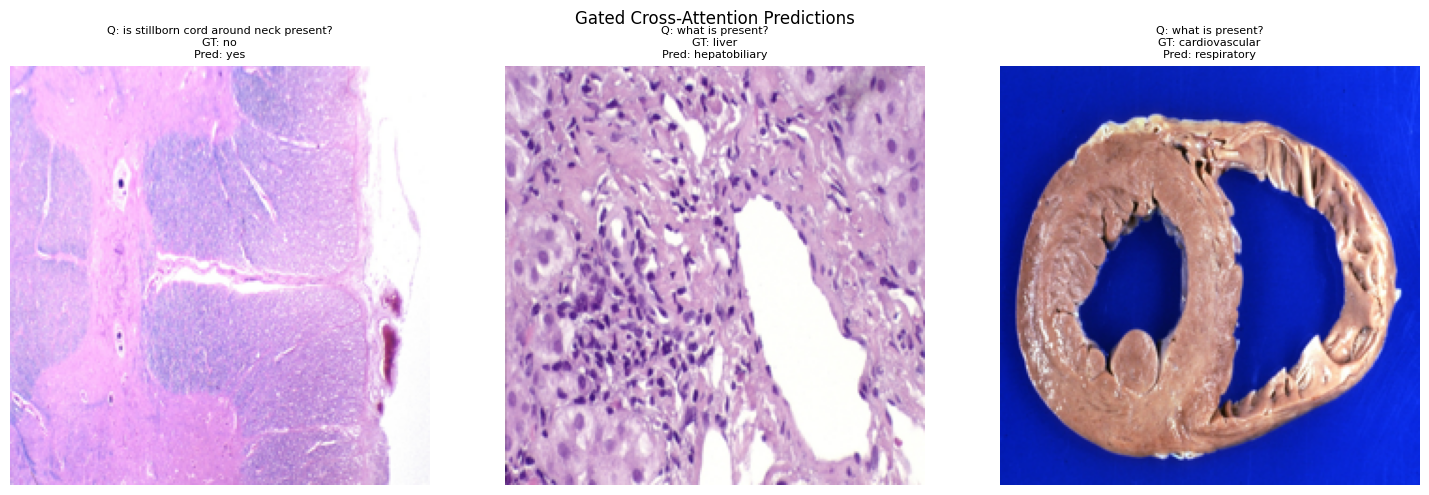

In [15]:
#run inference to collect the prediction visualisations
def generate_answer(model, image, question, max_new_tokens=20):
    model.eval()

    prompt = f"Question: {question}\nAnswer:"
    encoded = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    image = image.unsqueeze(0).to(device)

    generated = []

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(image, input_ids, attention_mask)
            next_token = torch.argmax(logits[:, -1, :], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

            generated.append(next_token.item())

            input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
            attention_mask = torch.cat(
                [attention_mask, torch.ones((1, 1), device=device)],
                dim=1
            )

    return tokenizer.decode(generated, skip_special_tokens=True).strip()


def plot_predictions(model, dataset, sample_indices, title):
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(15, 5))

    if len(sample_indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample_indices):
        image, question, answer = dataset[idx]
        pred = generate_answer(model, image, question)

        ax.imshow(image.permute(1, 2, 0))
        ax.axis("off")
        ax.set_title(
            f"Q: {question}\nGT: {answer}\nPred: {pred}",
            fontsize=8
        )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_predictions(
    model=cross_model,
    dataset=val_dataset,
    sample_indices=[2, 80, 7],
    title="Cross-Attention Predictions"
)

plot_predictions(
    model=gated_model,
    dataset=val_dataset,
    sample_indices=[2, 80, 7],
    title="Gated Cross-Attention Predictions"
)

#Inference: (Evaluation Metrics)

In [17]:
#run inference to collect the evaluation metrics (BLEU, ROUGE-L, and METEOR)
import evaluate
import nltk

# Required by METEOR in many notebook environments.
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")


def evaluate_predictions(model, dataset, n_samples=600):
    references = []
    predictions = []

    n_samples = min(n_samples, len(dataset))

    for i in tqdm(range(n_samples), desc="Evaluating"):
        image, question, answer = dataset[i]
        pred = generate_answer(model, image, question)

        references.append(answer)
        predictions.append(pred)

    bleu = evaluate.load("bleu")
    rouge = evaluate.load("rouge")
    meteor = evaluate.load("meteor")

    bleu_result = bleu.compute(predictions=predictions, references=references)
    rouge_result = rouge.compute(predictions=predictions, references=references)
    meteor_result = meteor.compute(predictions=predictions, references=references)

    metrics = {
        "BLEU": bleu_result["bleu"],
        "BLEU-1": bleu_result["precisions"][0],
        "BLEU-2": bleu_result["precisions"][1],
        "ROUGE-L": rouge_result["rougeL"],
        "METEOR": meteor_result["meteor"]
    }

    return metrics, references, predictions


cross_metrics, cross_refs, cross_preds = evaluate_predictions(
    model=cross_model,
    dataset=val_dataset,
    n_samples=600
)

print("Cross-Attention metrics:")
print(cross_metrics)

table1_cross = pd.DataFrame([
    {
        "Method": "Cross-Attention",
        "LR": 2e-4,
        "Epochs": 3,
        "Heads": 4,
        **cross_metrics
    }
])

print("Table 1. Cross-Attention Evaluation Metrics")
display(table1_cross)

gated_metrics, gated_refs, gated_preds = evaluate_predictions(
    model=gated_model,
    dataset=val_dataset,
    n_samples=600
)

print("Gated Cross-Attention metrics:")
print(gated_metrics)

table2_gated = pd.DataFrame([
    {
        "Method": "Gated Cross-Attention",
        "LR": 2e-4,
        "Epochs": 3,
        "Heads": 4,
        **gated_metrics
    }
])

print("Table 2. Gated Cross-Attention Evaluation Metrics")
display(table2_gated)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cross-Attention metrics:
{'BLEU': 0.0, 'BLEU-1': 0.2994428969359331, 'BLEU-2': 0.008333333333333333, 'ROUGE-L': np.float64(0.3475505050505051), 'METEOR': np.float64(0.17459732785379706)}
Table 1. Cross-Attention Evaluation Metrics


,Method,LR,Epochs,Heads,BLEU,BLEU-1,BLEU-2,ROUGE-L,METEOR
0,Cross-Attention,0.0002,3,4,0.0,0.299443,0.008333,0.347551,0.174597


Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Gated Cross-Attention metrics:
{'BLEU': 0.0, 'BLEU-1': 0.2730414746543779, 'BLEU-2': 0.011152416356877323, 'ROUGE-L': np.float64(0.3644731031638927), 'METEOR': np.float64(0.18464372057087153)}
Table 2. Gated Cross-Attention Evaluation Metrics


,Method,LR,Epochs,Heads,BLEU,BLEU-1,BLEU-2,ROUGE-L,METEOR
0,Gated Cross-Attention,0.0002,3,4,0.0,0.273041,0.011152,0.364473,0.184644


In [ ]:
RUN_HYPERPARAMETER_TUNING = True

cross_tuning_results = []

learning_rates = [1e-4, 2e-4, 3e-4]
epoch_list = [3, 5, 7]
num_heads = 4

baseline_lr = 2e-4
baseline_epochs = 3

if "cross_metrics" in globals():
    cross_tuning_results.append({
        "Method": "Cross-Attention",
        "Fusion": "cross",
        "LR": baseline_lr,
        "Epochs": baseline_epochs,
        "Heads": num_heads,
        **cross_metrics
    })
    print("Existing baseline result added: Cross lr=2e-4, epochs=3, heads=4")


if RUN_HYPERPARAMETER_TUNING:
    for lr in learning_rates:
        for epochs in epoch_list:

            # Skip the baseline if it has already been evaluated
            if "cross_metrics" in globals() and lr == baseline_lr and epochs == baseline_epochs:
                print(f"Skipping existing baseline: lr={lr}, epochs={epochs}")
                continue

            run_name = f"Cross_lr_{lr:.0e}_epoch{epochs}_heads{num_heads}"

            print("=" * 80)
            print("Running:", run_name)

            model = MedVQA(
                fusion_type="cross",
                num_heads=num_heads
            )

            model = train_model(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                epochs=epochs,
                lr=lr
            )

            metrics, refs, preds = evaluate_predictions(
                model=model,
                dataset=val_dataset,
                n_samples=600
            )

            cross_tuning_results.append({
                "Method": run_name,
                "Fusion": "cross",
                "LR": lr,
                "Epochs": epochs,
                "Heads": num_heads,
                **metrics
            })

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()


# Convert results to dataframe
cross_tuning_table = pd.DataFrame(cross_tuning_results)

# Composite score for selecting the best setting
# BLEU is often 0 for short-answer VQA, so BLEU-1, ROUGE-L and METEOR are used.
cross_tuning_table["Score"] = (
    0.30 * cross_tuning_table["BLEU-1"] +
    0.40 * cross_tuning_table["ROUGE-L"] +
    0.30 * cross_tuning_table["METEOR"]
)

cross_tuning_table = cross_tuning_table.sort_values(
    by="Score",
    ascending=False
).reset_index(drop=True)

print("Cross-Attention hyperparameter tuning results:")
display(cross_tuning_table)

best_cross_result = cross_tuning_table.iloc[0]

print("Best Cross-Attention hyperparameter setting:")
print(best_cross_result)

Existing baseline result added: Cross lr=2e-4, epochs=3, heads=4
Running: Cross_lr_1e-04_epoch3_heads4


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Training epoch 1:   0%|          | 0/75 [00:00<?, ?it/s]

...

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Running: Cross_lr_1e-04_epoch5_heads4


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/75 [00:00<?, ?it/s]